In [1]:
!pip install xlrd 

In [47]:
!pip install mlflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.0 which is incompatible.


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/8.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.8 MB 1.9 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.8 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/8.8 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.8 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.1/8.8 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.8 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 2.9/8.8 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.8 MB 1.8 MB/s eta 0:00:04
   ---------------- ----------------------- 3.7/8.8 MB 1.8 MB/s eta 0:00:03
   ------------------- -------------------- 4.2/8.8 MB 1.9 MB/s eta 0:00:03
   -------------------- ---

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
from custom_transformers import IQRCapper
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8 (1).xls")

# Basic Checks

In [4]:
df.head(5)

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [6]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [7]:
df.describe(include='object')

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E1001000,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


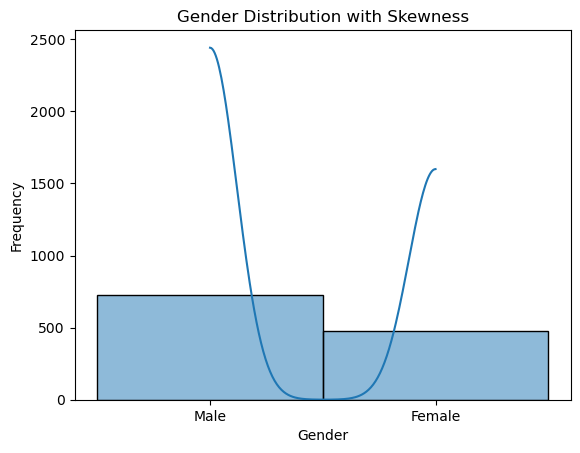

In [8]:
sns.histplot(df['Gender'], kde=True)
plt.title('Gender Distribution with Skewness')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

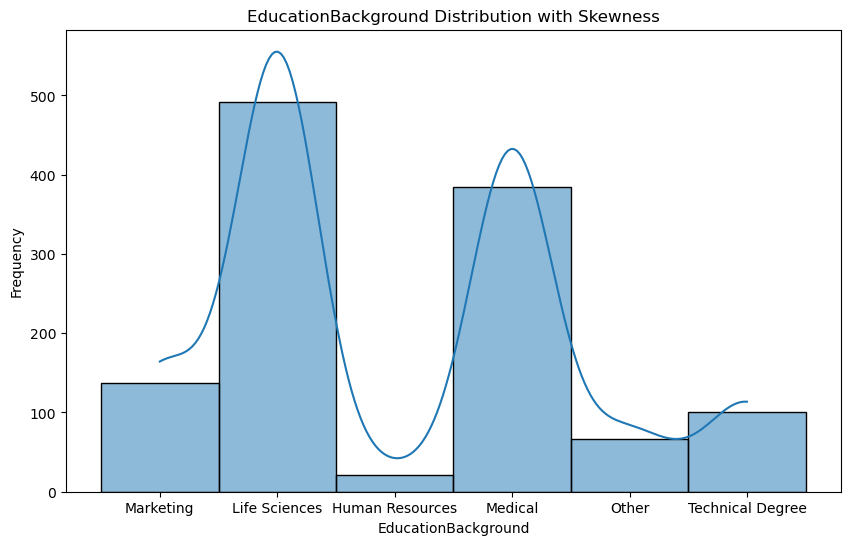

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EducationBackground'], kde=True)
plt.title('EducationBackground Distribution with Skewness')
plt.xlabel('EducationBackground')
plt.ylabel('Frequency')
plt.show()

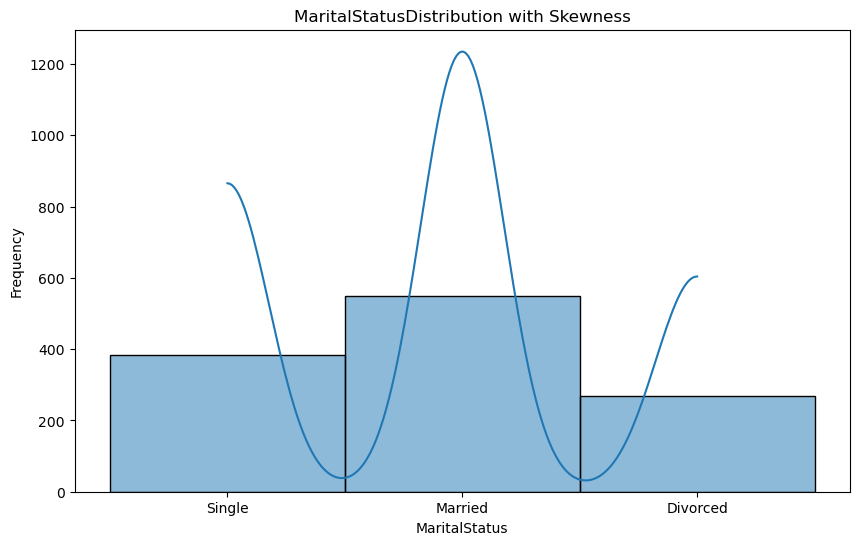

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MaritalStatus'], kde=True)
plt.title('MaritalStatusDistribution with Skewness')
plt.xlabel('MaritalStatus')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='EmpNumber', ylabel='DistanceFromHome'>

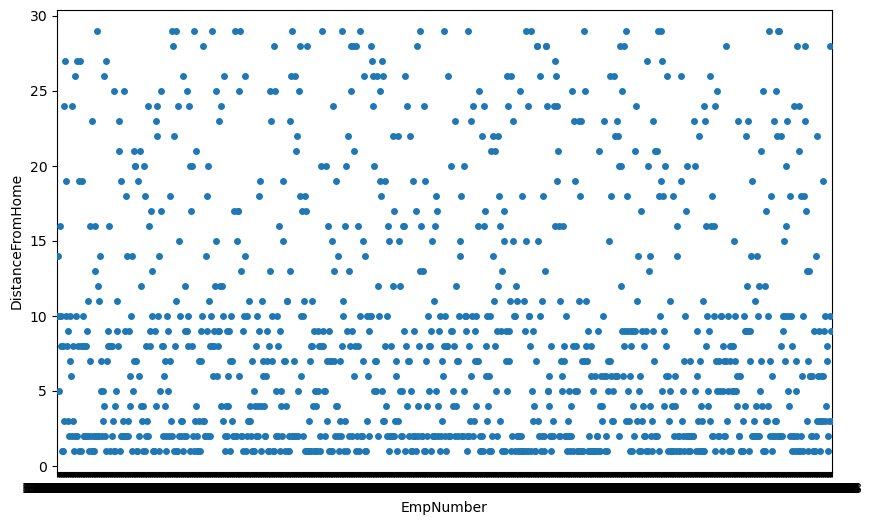

In [11]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='EmpNumber', y='DistanceFromHome', data=df, jitter=True) # As per my analysis distance from might not be the case of bad perfrmance
#because as we can see in this distance from home is 30 km and our mostly empyloees are within 15 km 

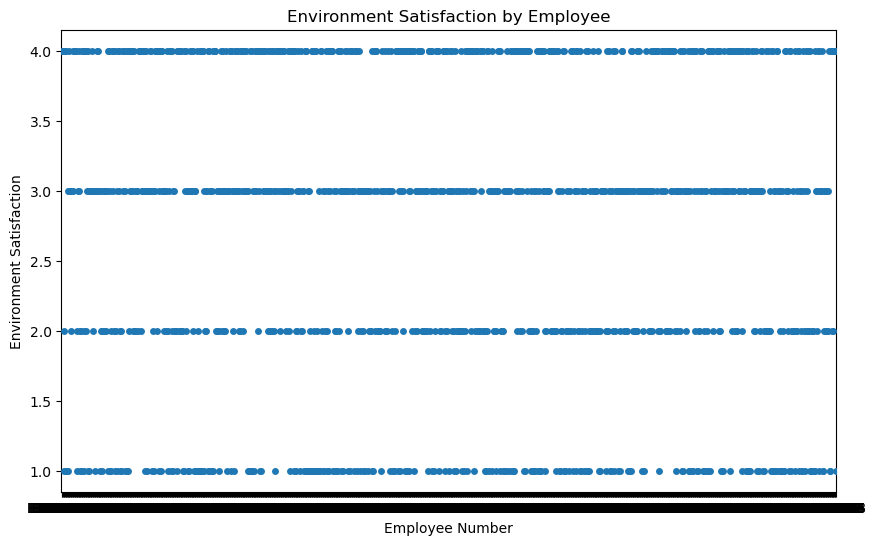

In [12]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='EmpNumber', y='EmpEnvironmentSatisfaction', data=df, jitter=True)
plt.title('Environment Satisfaction by Employee')
plt.xlabel('Employee Number')
plt.ylabel('Environment Satisfaction')
plt.show() #as we can see mostly employees  envirnment satisfaction rate is  3 out of 4 so , it's a remark good for us because our mostly employees are
#satisfy with the work still we can slowly improve our envirnmt so, we can attract best employee for our company.

In [13]:
df['EmpEnvironmentSatisfaction'].median()

3.0

In [14]:
numeric_cols = df.select_dtypes(include='number').columns

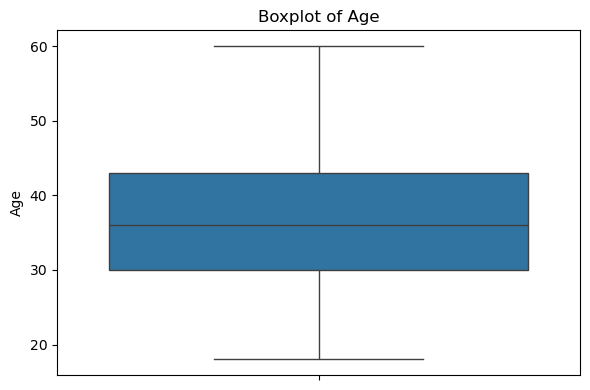

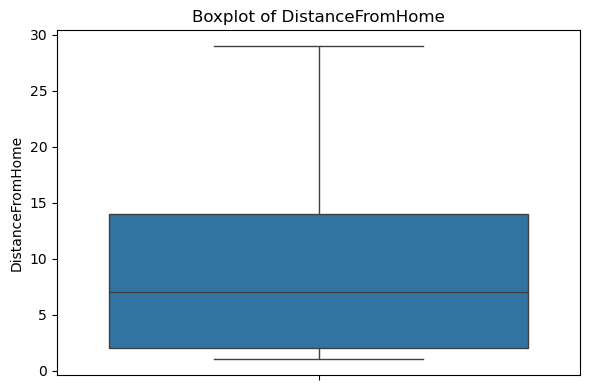

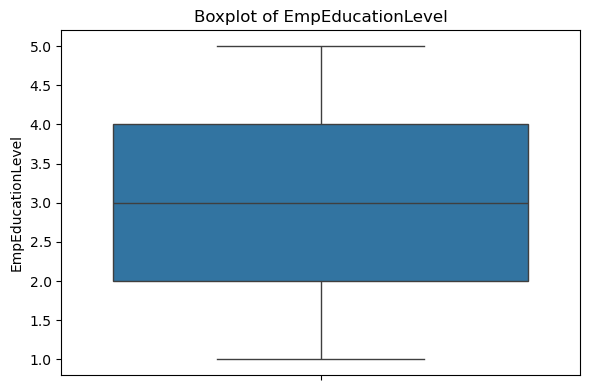

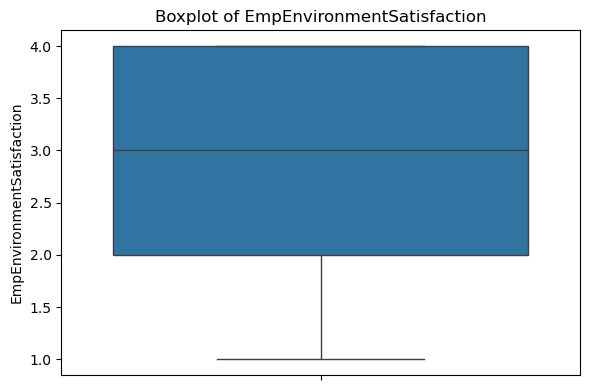

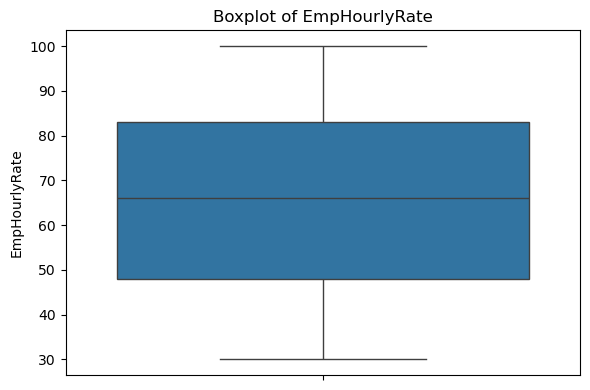

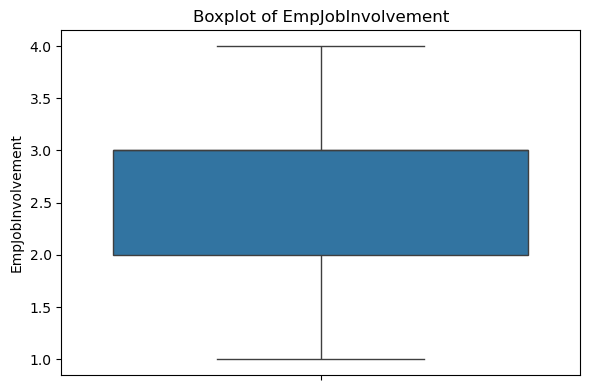

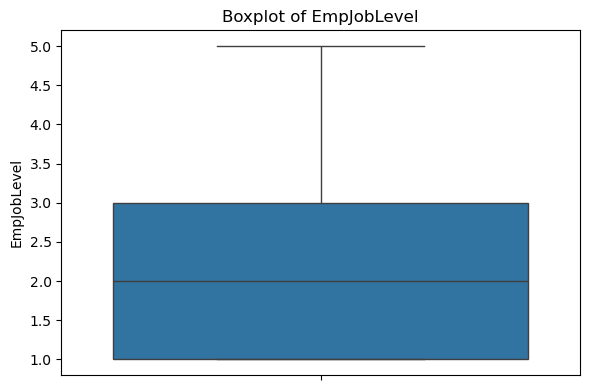

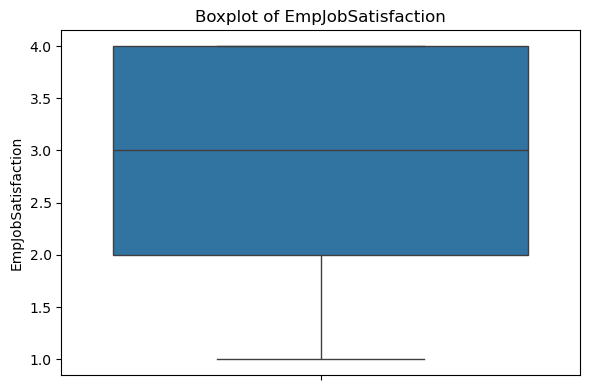

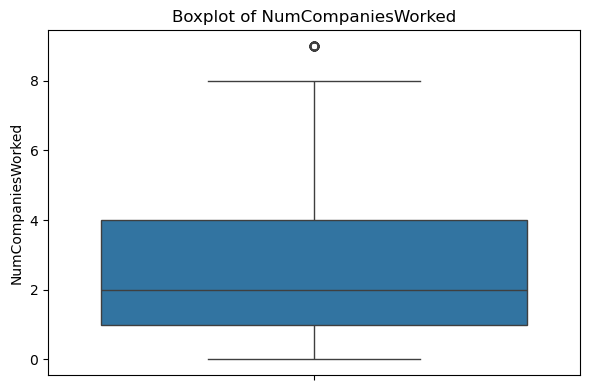

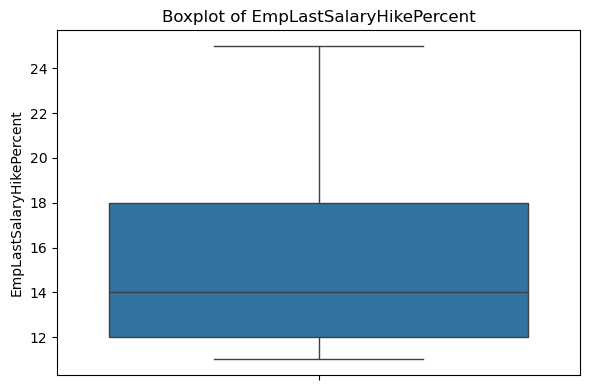

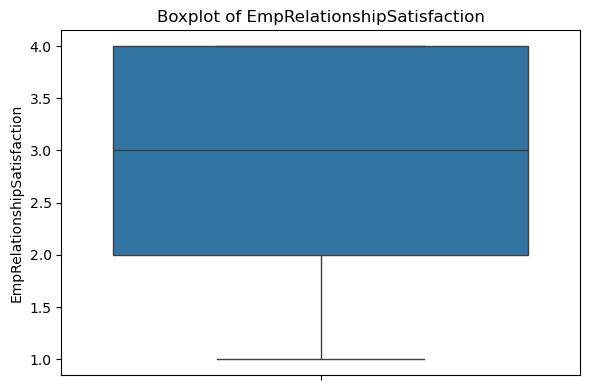

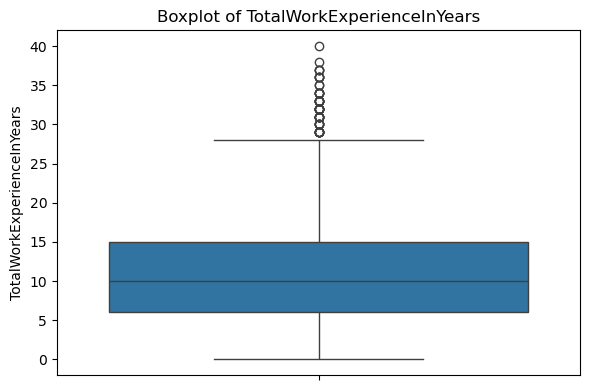

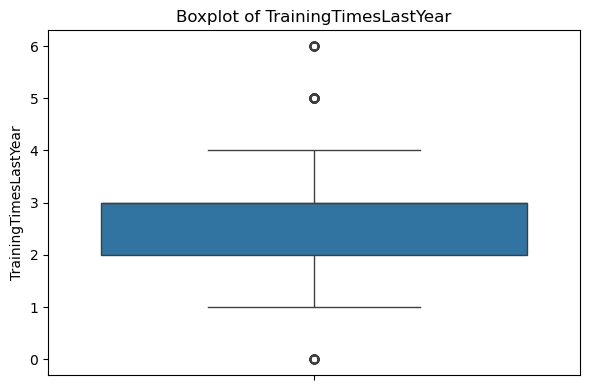

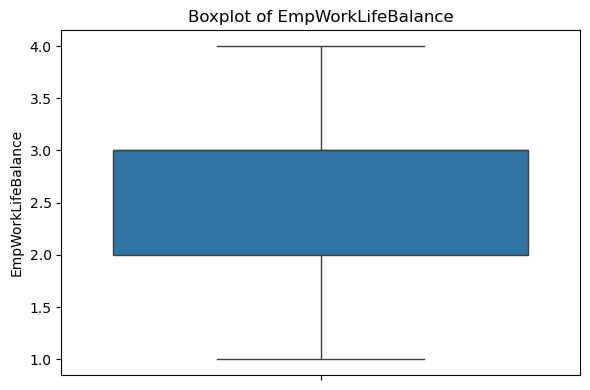

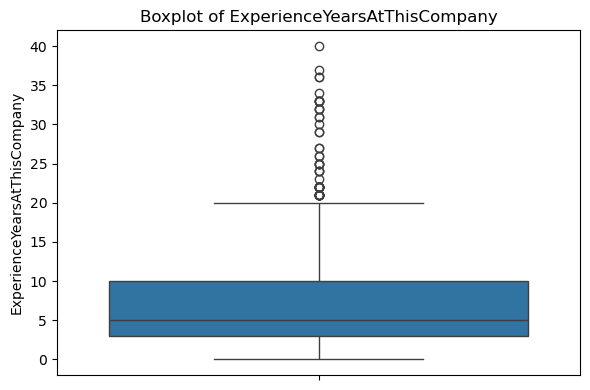

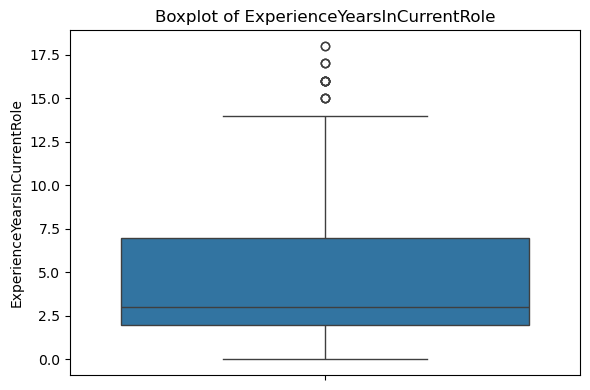

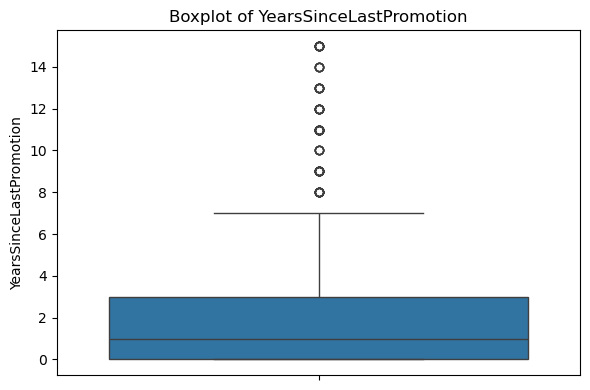

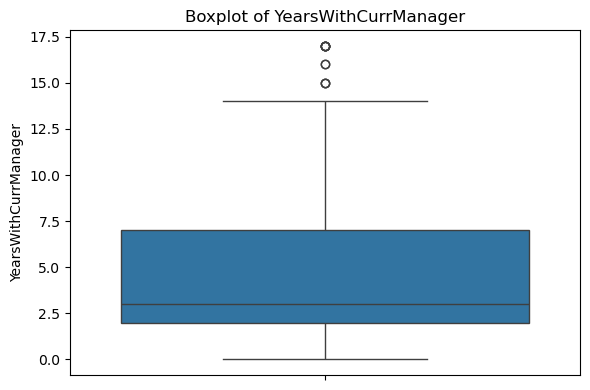

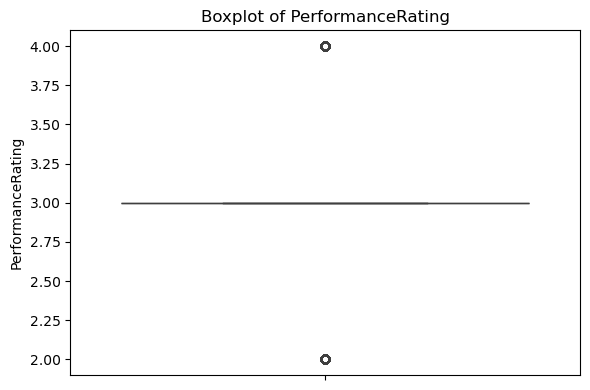

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [16]:
# Loop through each numeric column
for col in numeric_cols:
    median = df[col].median()
    mad = (df[col] - median).abs().median()
    
    # Avoid division by zero
    if mad == 0:
        print(f"{col}: MAD is zero, skipping.")
        continue
    
    # Calculate modified Z-score
    df[f'{col}_mod_z'] = 0.6745 * (df[col] - median) / mad
    
    # Identify outliers
    outliers = df[df[f'{col}_mod_z'].abs() > 3.5]
    
    print(f"{col}: {len(outliers)} outliers detected")

Age: 0 outliers detected
DistanceFromHome: 0 outliers detected
EmpEducationLevel: 0 outliers detected
EmpEnvironmentSatisfaction: 0 outliers detected
EmpHourlyRate: 0 outliers detected
EmpJobInvolvement: MAD is zero, skipping.
EmpJobLevel: 0 outliers detected
EmpJobSatisfaction: 0 outliers detected
NumCompaniesWorked: 79 outliers detected
EmpLastSalaryHikePercent: 13 outliers detected
EmpRelationshipSatisfaction: 0 outliers detected
TotalWorkExperienceInYears: 38 outliers detected
TrainingTimesLastYear: 0 outliers detected
EmpWorkLifeBalance: MAD is zero, skipping.
ExperienceYearsAtThisCompany: 56 outliers detected
ExperienceYearsInCurrentRole: 0 outliers detected
YearsSinceLastPromotion: 150 outliers detected
YearsWithCurrManager: 0 outliers detected
PerformanceRating: MAD is zero, skipping.


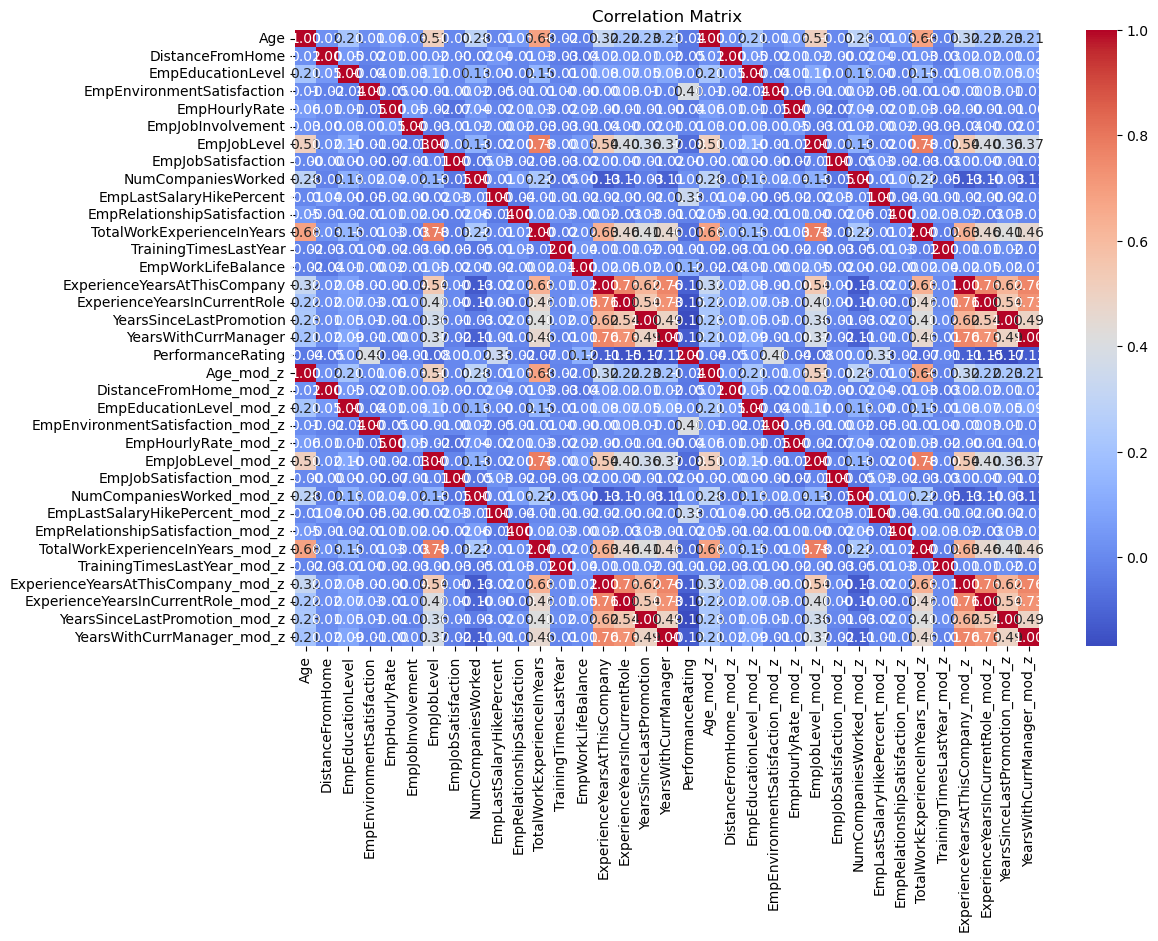

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [18]:
df.corr(numeric_only=True)['PerformanceRating'].sort_values(ascending=False)

PerformanceRating                     1.000000
EmpEnvironmentSatisfaction_mod_z      0.395561
EmpEnvironmentSatisfaction            0.395561
EmpLastSalaryHikePercent_mod_z        0.333722
EmpLastSalaryHikePercent              0.333722
EmpWorkLifeBalance                    0.124429
NumCompaniesWorked                    0.020980
NumCompaniesWorked_mod_z              0.020980
EmpEducationLevel                     0.020529
EmpEducationLevel_mod_z               0.020529
EmpJobSatisfaction_mod_z              0.000606
EmpJobSatisfaction                    0.000606
TrainingTimesLastYear                -0.005443
TrainingTimesLastYear_mod_z          -0.005443
EmpJobInvolvement                    -0.010539
EmpRelationshipSatisfaction          -0.019502
EmpRelationshipSatisfaction_mod_z    -0.019502
Age                                  -0.040164
Age_mod_z                            -0.040164
EmpHourlyRate                        -0.043116
EmpHourlyRate_mod_z                  -0.043116
DistanceFromH

In [19]:
# Custom outlier handler using Modified Z-score
class ModifiedZScoreOutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3.5):
        self.threshold = threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            median = X[col].median()
            mad = (X[col] - median).abs().median()
            if mad == 0:
                continue
            mod_z = 0.6745 * (X[col] - median) / mad
            X.loc[mod_z.abs() > self.threshold, col] = np.nan  # mark outliers as missing
        return X


In [20]:
numeric_cols = ['Age', 'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion']
categorical_cols = ['EmpDepartment', 'Gender']


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   EmpNumber                           1200 non-null   object 
 1   Age                                 1200 non-null   int64  
 2   Gender                              1200 non-null   object 
 3   EducationBackground                 1200 non-null   object 
 4   MaritalStatus                       1200 non-null   object 
 5   EmpDepartment                       1200 non-null   object 
 6   EmpJobRole                          1200 non-null   object 
 7   BusinessTravelFrequency             1200 non-null   object 
 8   DistanceFromHome                    1200 non-null   int64  
 9   EmpEducationLevel                   1200 non-null   int64  
 10  EmpEnvironmentSatisfaction          1200 non-null   int64  
 11  EmpHourlyRate                       1200 no

In [22]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [23]:
cat_cols = df.select_dtypes(include='object').columns

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        score = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
        print(f"{cat_cols[i]} vs {cat_cols[j]}: {score:.3f}")

EmpNumber vs Gender: nan
EmpNumber vs EducationBackground: nan
EmpNumber vs MaritalStatus: nan
EmpNumber vs EmpDepartment: inf
EmpNumber vs EmpJobRole: nan
EmpNumber vs BusinessTravelFrequency: nan


C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value enc

EmpNumber vs OverTime: nan
EmpNumber vs Attrition: nan
Gender vs EducationBackground: 0.000
Gender vs MaritalStatus: 0.011
Gender vs EmpDepartment: 0.000
Gender vs EmpJobRole: 0.104
Gender vs BusinessTravelFrequency: 0.038
Gender vs OverTime: 0.022
Gender vs Attrition: 0.017
EducationBackground vs MaritalStatus: 0.000
EducationBackground vs EmpDepartment: 0.361
EducationBackground vs EmpJobRole: 0.333
EducationBackground vs BusinessTravelFrequency: 0.000
EducationBackground vs OverTime: 0.000
EducationBackground vs Attrition: 0.102
MaritalStatus vs EmpDepartment: 0.039
MaritalStatus vs EmpJobRole: 0.000
MaritalStatus vs BusinessTravelFrequency: 0.049
MaritalStatus vs OverTime: 0.000
MaritalStatus vs Attrition: 0.182
EmpDepartment vs EmpJobRole: 0.975
EmpDepartment vs BusinessTravelFrequency: 0.000
EmpDepartment vs OverTime: 0.026
EmpDepartment vs Attrition: 0.059
EmpJobRole vs BusinessTravelFrequency: 0.000
EmpJobRole vs OverTime: 0.070
EmpJobRole vs Attrition: 0.163
BusinessTravelFreq

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_6276\595642539.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   EmpNumber                           1200 non-null   object 
 1   Age                                 1200 non-null   int64  
 2   Gender                              1200 non-null   object 
 3   EducationBackground                 1200 non-null   object 
 4   MaritalStatus                       1200 non-null   object 
 5   EmpDepartment                       1200 non-null   object 
 6   EmpJobRole                          1200 non-null   object 
 7   BusinessTravelFrequency             1200 non-null   object 
 8   DistanceFromHome                    1200 non-null   int64  
 9   EmpEducationLevel                   1200 non-null   int64  
 10  EmpEnvironmentSatisfaction          1200 non-null   int64  
 11  EmpHourlyRate                       1200 no

In [25]:
%%writefile custom_transformers.py
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        self.bounds_ = {}
        X = pd.DataFrame(X)
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - self.factor * IQR
            upper = Q3 + self.factor * IQR
            self.bounds_[col] = (lower, upper)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lower, upper = self.bounds_[col]
            X[col] = X[col].clip(lower, upper)  # cap values
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

Overwriting custom_transformers.py


In [26]:
X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']


In [27]:
numeric_cols = [
    'Age', 'EmpLastSalaryHikePercent', 'EmpEnvironmentSatisfaction',
    'YearsSinceLastPromotion', 'EmpHourlyRate', 'DistanceFromHome'
]

categorical_cols = [
    'Gender', 'EducationBackground', 'MaritalStatus',
    'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime'
]


In [28]:
from custom_transformers import IQRCapper
numeric_pipeline = Pipeline([
    ('outlier_handler', IQRCapper(factor=1.5)),   # or Winsorizer(lower_quantile=0.01, upper_quantile=0.99)
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])
joblib.dump(preprocessor, 'preprocessor_pipeline.pkl')

['preprocessor_pipeline.pkl']

In [29]:
preprocessor = joblib.load("preprocessor_pipeline.pkl")

In [30]:
svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('outlier_handler',
                                                                   IQRCapper()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'EmpLastSalaryHikePercent',
                                                   'EmpEnvironmentSatisfaction',
                                                   'YearsSinceLastPromotion',
                                                   'EmpHourlyRate',
                                                   'DistanceFromHome']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'EducationBackground',
                                                   'MaritalStatus',
                                                   'EmpDepartment',
                                                   'EmpJobRole',
                                                   'BusinessTravelFrequency',
                                                   'OverTime'])])),
                ('classifier', SVC())])

In [33]:
y_pred = svm_pipeline.predict(X_test)
y_pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 4, 3, 3, 3, 3, 3, 2, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3,
       3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 2, 2, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 2, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 2, 3, 3, 3, 3, 3, 4, 3, 3,
       3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3,
       3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3,
       4, 3, 3, 4, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2],
      dtype=int64)

In [34]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[ 18  21   0]
 [  5 169   1]
 [  1  17   8]]

Classification Report:
               precision    recall  f1-score   support

           2       0.75      0.46      0.57        39
           3       0.82      0.97      0.88       175
           4       0.89      0.31      0.46        26

    accuracy                           0.81       240
   macro avg       0.82      0.58      0.64       240
weighted avg       0.81      0.81      0.79       240



In [35]:

from sklearn.model_selection import GridSearchCV
# Define parameter grid for SVM inside the pipeline
param_grid = {
    'classifier__C': [0.1, 1, 10, 50, 100],
    'classifier__gamma': ['scale', 0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf'],   # stick with RBF for now
    'classifier__class_weight': ['balanced']  # handle imbalance
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,                        # 5-fold cross-validation
    scoring='f1_macro',          # macro F1 to balance all classes
    n_jobs=-1,                   # use all CPU cores
    verbose=2
)
# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Macro F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best Macro F1 Score: 0.7392663646612816


In [36]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[ 24  14   1]
 [  6 167   2]
 [  2  10  14]]

Classification Report:
               precision    recall  f1-score   support

           2       0.75      0.62      0.68        39
           3       0.87      0.95      0.91       175
           4       0.82      0.54      0.65        26

    accuracy                           0.85       240
   macro avg       0.82      0.70      0.75       240
weighted avg       0.85      0.85      0.85       240



In [37]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 31   8   0]
 [  5 170   0]
 [  1   8  17]]
              precision    recall  f1-score   support

           2       0.84      0.79      0.82        39
           3       0.91      0.97      0.94       175
           4       1.00      0.65      0.79        26

    accuracy                           0.91       240
   macro avg       0.92      0.81      0.85       240
weighted avg       0.91      0.91      0.90       240



In [38]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

lgbm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        class_weight='balanced',
        random_state=42
    ))
])

In [39]:
lgbm_pipeline.fit(X_train, y_train)
y_pred = lgbm_pipeline.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 243
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 39
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[ 32   7   0]
 [  8 166   1]
 [  1   6  19]]

Classification Report:
               precision    recall  f1-score   support

           2       0.78      0.82      0.80        39
           3       0.93      0.95      0.94       175
           4       0.95      0.73      0.83        26

    accuracy                           0.90       240
   macro avg       0.89      0.83      0.85       240
weighted avg       0.91      0.90      0.90       240



In [41]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Encode target labels to start from 0
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Step 2: Define pipeline
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
])

# Step 3: Fit and predict
xgb_pipeline.fit(X_train, y_train_encoded)
y_pred_encoded = xgb_pipeline.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

# Step 4: Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

C:\Users\Dhruv\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:32:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[ 32   7   0]
 [  5 170   0]
 [  1   6  19]]

Classification Report:
               precision    recall  f1-score   support

           2       0.84      0.82      0.83        39
           3       0.93      0.97      0.95       175
           4       1.00      0.73      0.84        26

    accuracy                           0.92       240
   macro avg       0.92      0.84      0.88       240
weighted avg       0.92      0.92      0.92       240



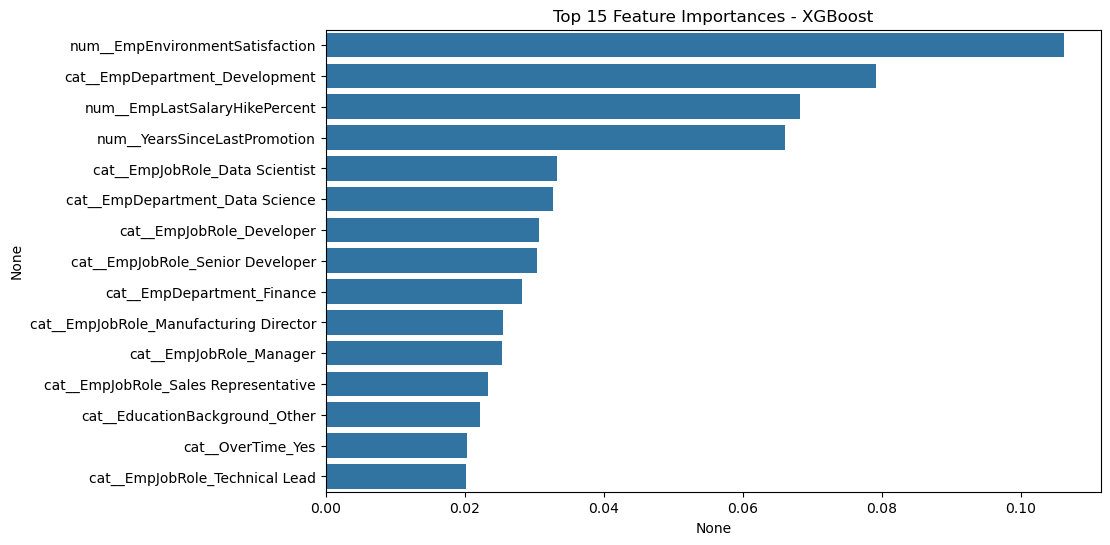

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = preprocessor.get_feature_names_out()
importances = xgb_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:15]

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

In [43]:
import joblib
joblib.dump(xgb_pipeline, 'xgb_hr_model.pkl')

['xgb_hr_model.pkl']

In [44]:
probs = xgb_pipeline.predict_proba(X_test)

In [45]:
probs

array([[5.02637401e-03, 9.94369209e-01, 6.04403089e-04],
       [8.51461591e-05, 9.99646425e-01, 2.68452568e-04],
       [4.01338039e-04, 9.99026179e-01, 5.72434627e-04],
       [9.43479061e-01, 5.36130480e-02, 2.90790922e-03],
       [1.87341284e-05, 9.99819458e-01, 1.61781994e-04],
       [1.97804044e-03, 9.93138850e-01, 4.88310494e-03],
       [9.16126430e-01, 8.27487856e-02, 1.12472731e-03],
       [1.08379936e-04, 9.99192536e-01, 6.99061144e-04],
       [8.74856114e-01, 1.22613363e-01, 2.53052777e-03],
       [3.21357831e-04, 9.97372389e-01, 2.30624224e-03],
       [6.34106458e-04, 9.99010444e-01, 3.55465774e-04],
       [7.83733547e-01, 2.14746088e-01, 1.52039260e-03],
       [7.36670263e-05, 9.99216080e-01, 7.10185675e-04],
       [9.51249458e-05, 9.95257556e-01, 4.64733457e-03],
       [3.67738794e-05, 9.93146837e-01, 6.81632664e-03],
       [2.14896537e-03, 9.96017873e-01, 1.83313759e-03],
       [3.32764466e-03, 9.95500743e-01, 1.17162417e-03],
       [2.38674256e-04, 9.99656

In [46]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

# Load model
model = joblib.load('xgb_hr_model.pkl')

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    df = pd.DataFrame(data)
    preds = model.predict(df)
    return jsonify({'predictions': preds.tolist()})

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\Dhruv\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [48]:
import mlflow
import subprocess

# Get current Git commit hash
commit_hash = subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode('utf-8').strip()

# Start MLflow run
mlflow.set_experiment("PerformanceRating")
with mlflow.start_run():
    mlflow.set_tag("git_commit", commit_hash)

    # Log parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)

    # Train and evaluate
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("f1_macro", f1_score(y_test, y_pred, average='macro'))

    # Log model
    mlflow.sklearn.log_model(model, "model")

    # Optional: log artifacts
    
    plt.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")

CalledProcessError: Command '['git', 'rev-parse', 'HEAD']' returned non-zero exit status 128.